INFO     | ======================================================================
INFO     | Starting analysis: figure_02_spatial_diagnostics
INFO     | Log file: outputs/logs/figure_02_spatial_diagnostics_20260622_125047.log
INFO     | Timestamp: 2026-06-22 12:50:47
INFO     | ======================================================================
INFO     | Configuration loaded
INFO     | Loading GLORYS12 data from: ../../glorys12_with_density/glorys12_*_Greenland_Sea_with_density.nc
INFO     | Time: 1993-01-01 → 2025-11-01
INFO     | Processing: Creating Greenland Sea mask
INFO     | Masked cells: 30496
INFO     | Processing: Computing per-cell SIV budget
INFO     |   Grid spacing: dy=9.27 km, dx range 1.77–3.02 km
INFO     |   Computing flux divergence (centred differences)...
INFO     |   Computing dSIV/dt per cell...
INFO     |   Computing (this may take several minutes)...
INFO     |   Domain closure: max |residual| = 0.000000 km³
INFO     | Created netcdf: siv_budget_monthly.nc


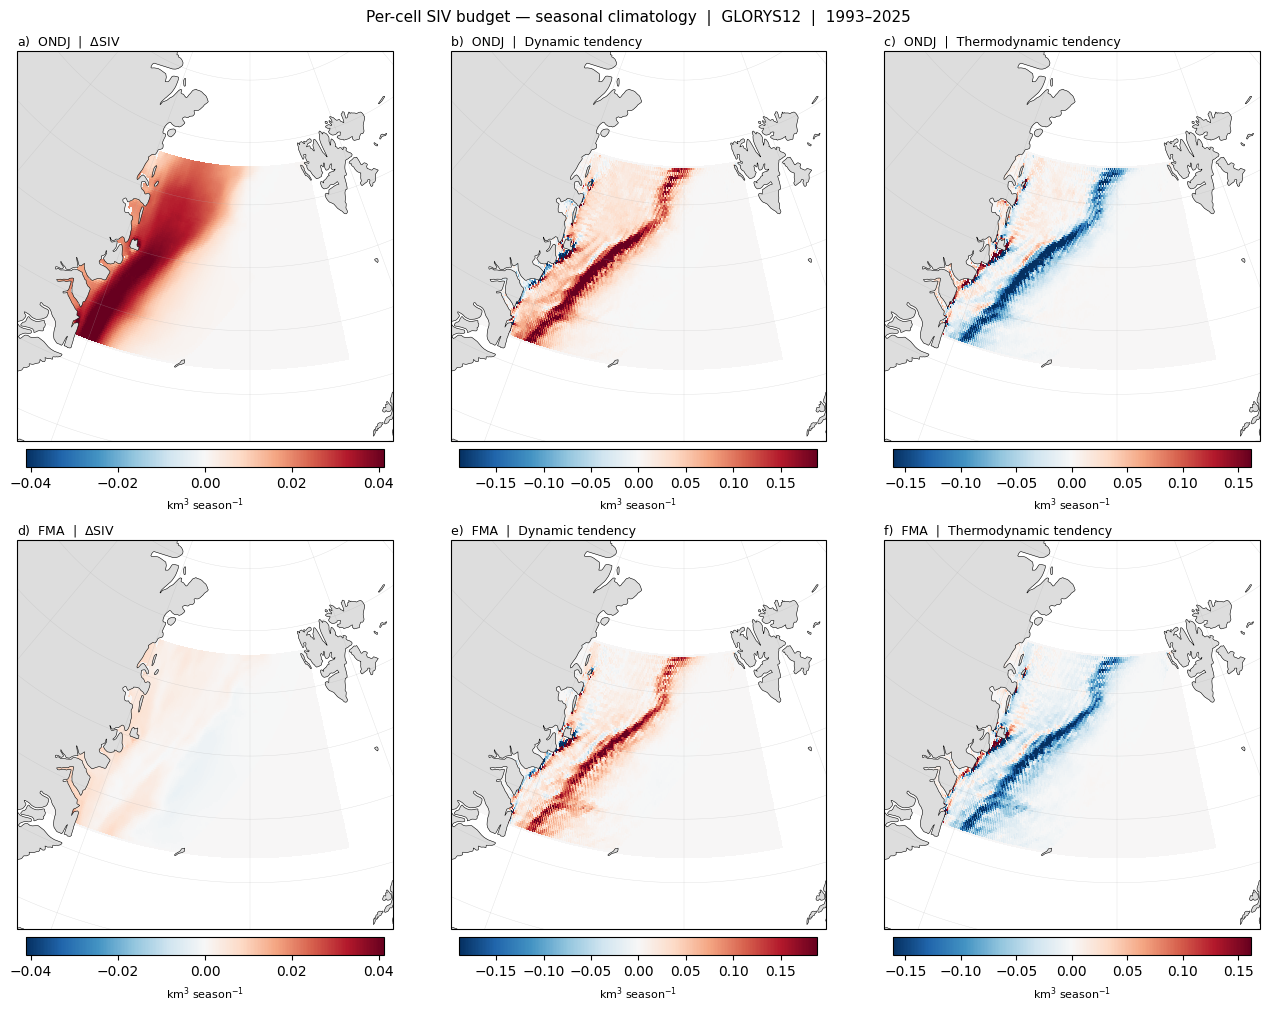

INFO     | Created figure: figure_02_spatial_diagnostics_trend_maps.png


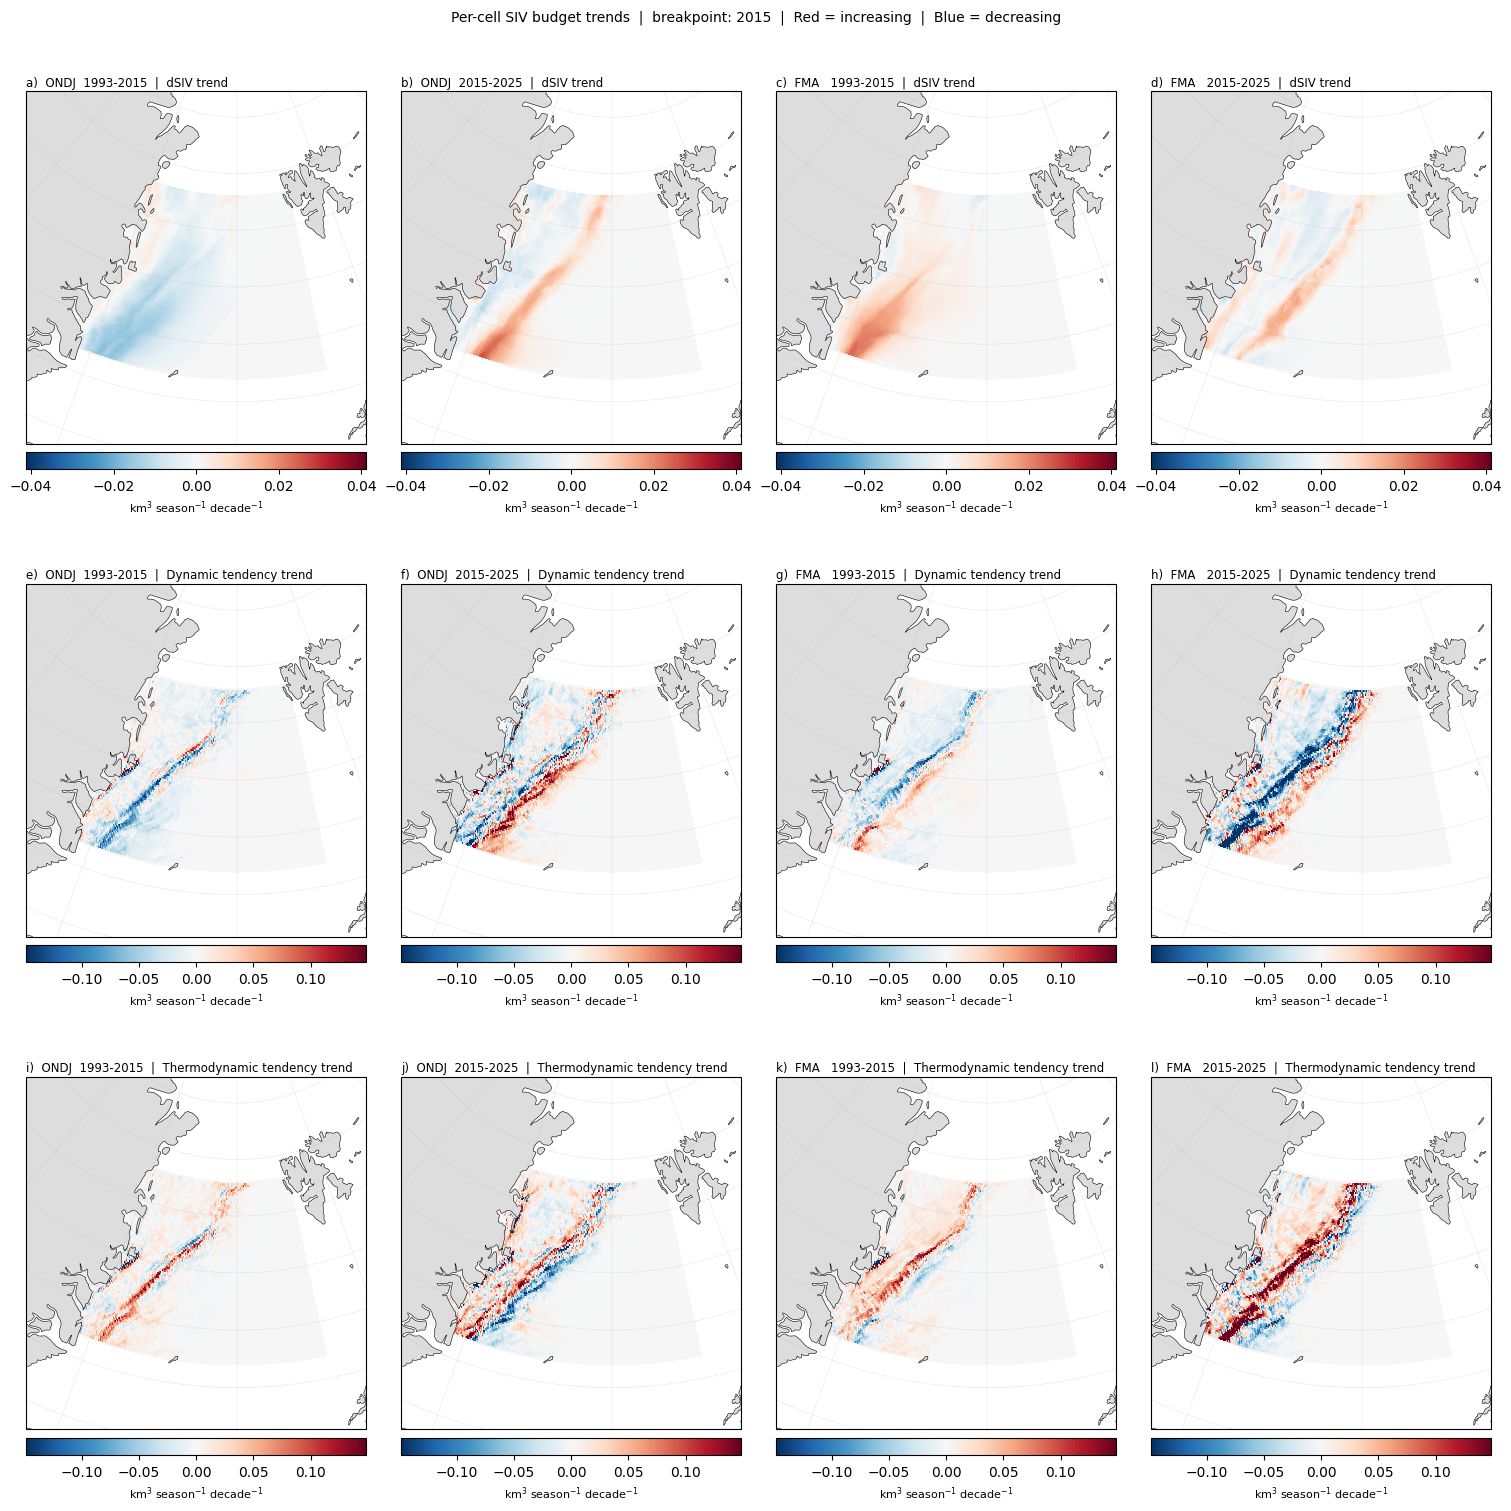

INFO     | Processing: Computing thermodynamic growth/melt trend maps
INFO     |   Computing sign-partitioned seasonal sums...
INFO     |   thermo_growth early: years 1994–2025, n=32
INFO     |   thermo_melt early: years 1994–2025, n=32
INFO     |   thermo_growth late: years 1993–2025, n=33
INFO     |   thermo_melt late: years 1993–2025, n=33
INFO     | Created netcdf: siv_thermo_growth_melt_seasonal.nc
INFO     |   Computing piecewise OLS slopes for growth/melt...
INFO     |     growth_early_p1_slope  (n=23 years)...
INFO     |     growth_early_p2_slope  (n=11 years)...
INFO     |     growth_late_p1_slope  (n=23 years)...
INFO     |     growth_late_p2_slope  (n=11 years)...
INFO     |     melt_early_p1_slope  (n=23 years)...
INFO     |     melt_early_p2_slope  (n=11 years)...
INFO     |     melt_late_p1_slope  (n=23 years)...
INFO     |     melt_late_p2_slope  (n=11 years)...
INFO     | Created figure: figure_02_spatial_diagnostics_thermo_growth_melt_trends.png


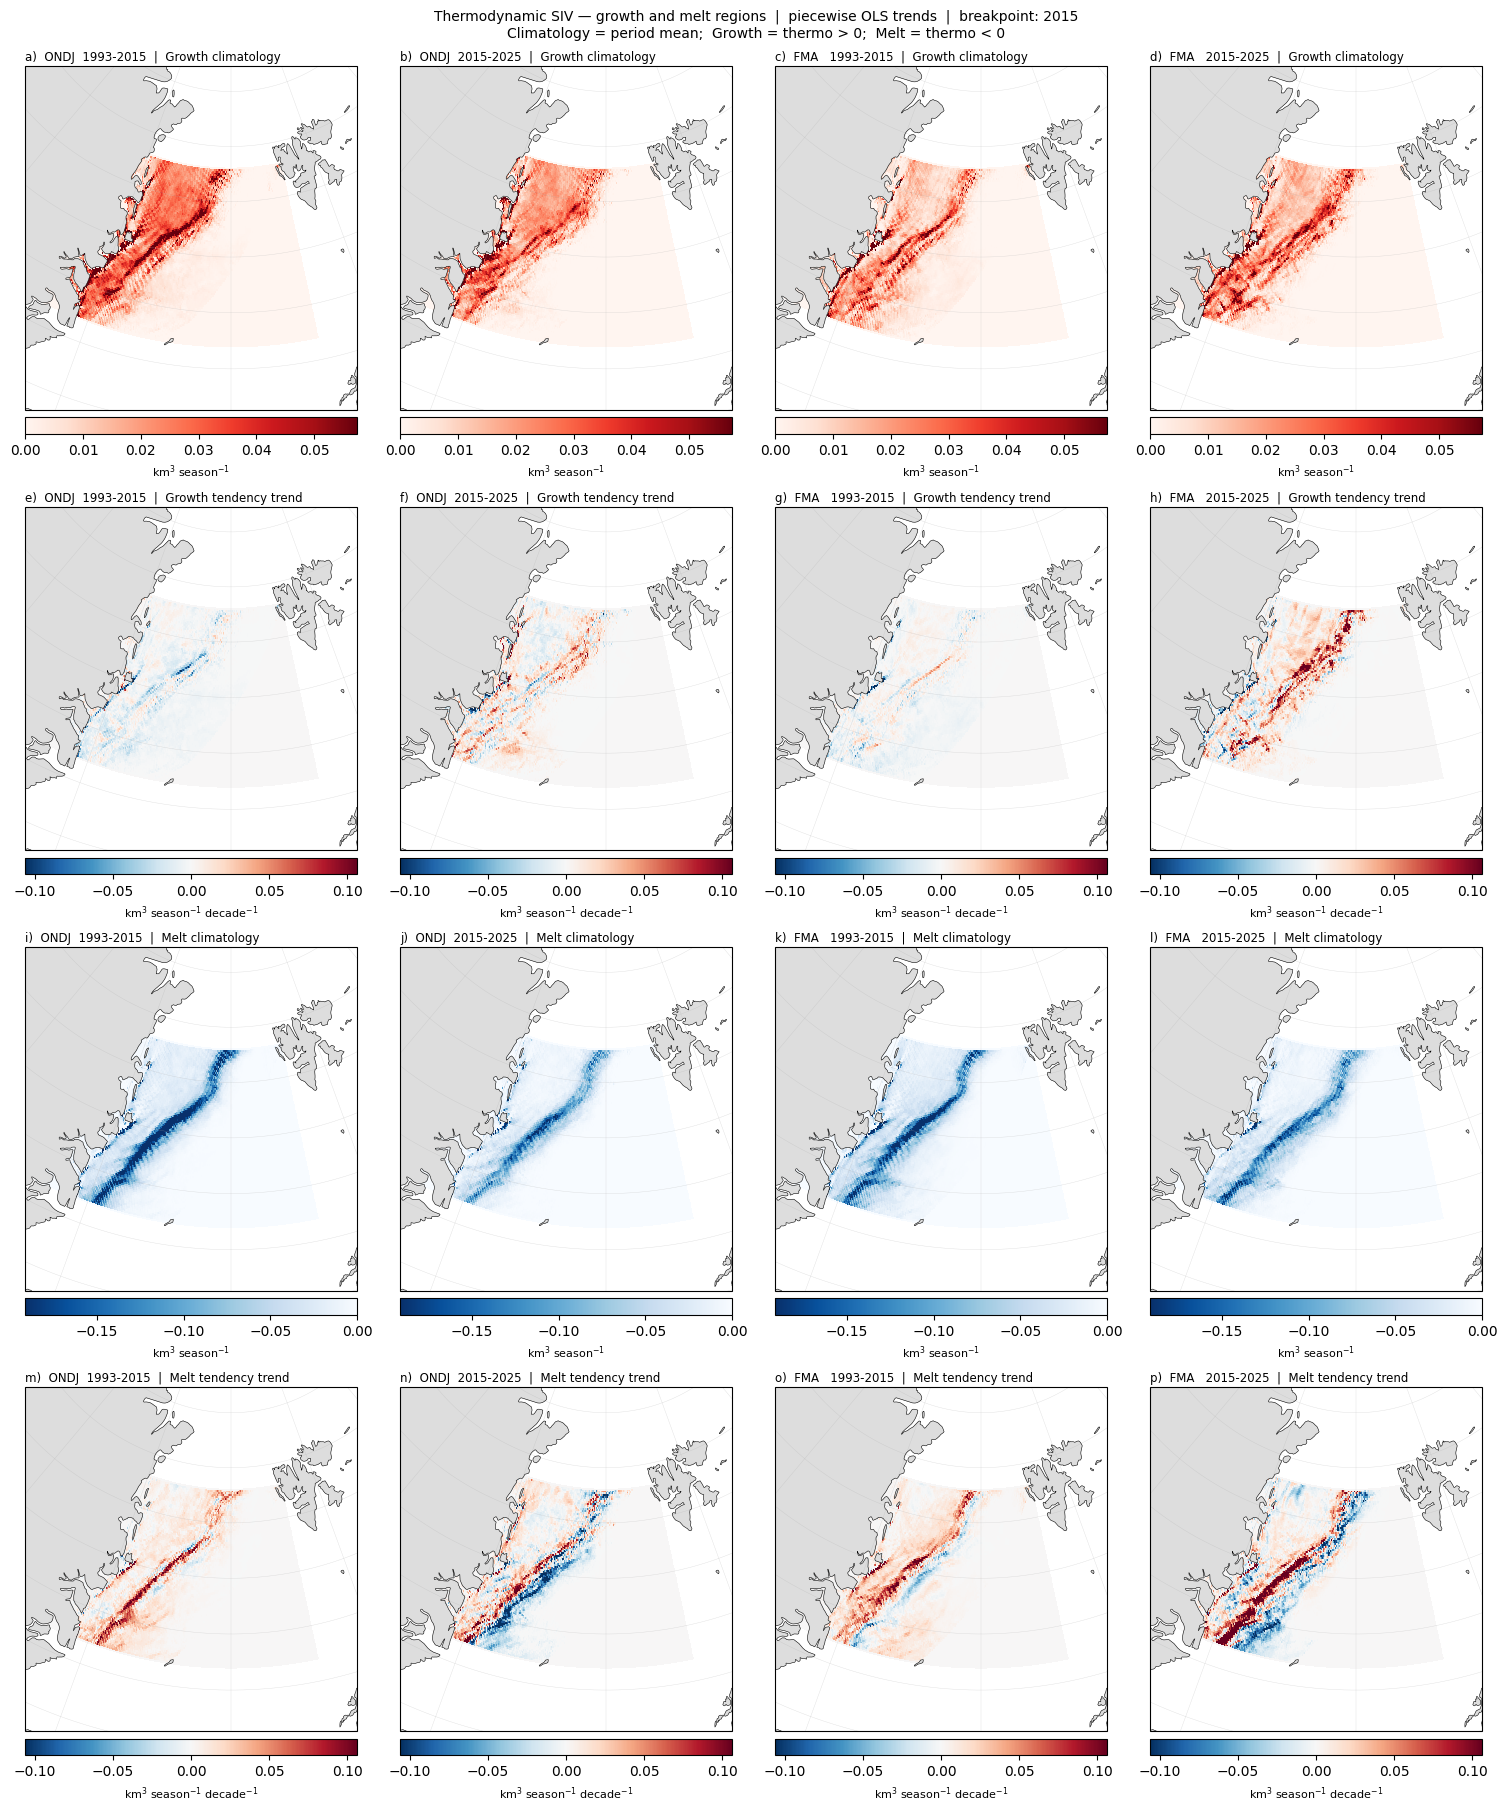

INFO     | Processing: Domain-integrated timeseries for cross-check
INFO     |   thermo_growth early: 1994–2025, n=32
INFO     |   thermo_growth late: 1993–2025, n=33
INFO     |   thermo_melt early: 1994–2025, n=32
INFO     |   thermo_melt late: 1993–2025, n=33
INFO     |   div_import early: 1994–2025, n=32
INFO     |   div_import late: 1993–2025, n=33
INFO     |   div_export early: 1994–2025, n=32
INFO     |   div_export late: 1993–2025, n=33
INFO     |   dsiv early: 1994–2025, n=32
INFO     |   dsiv late: 1993–2025, n=33
INFO     | Created csv: domain_growth_melt_early.csv
INFO     | Created csv: domain_growth_melt_late.csv
INFO     | Created methods: figure_02_spatial_diagnostics_methods.md
INFO     | Methods written: outputs/methods/figure_02_spatial_diagnostics_methods.md
INFO     | ======================================================================
INFO     | Analysis completed successfully
INFO     | Total elapsed time: 0:02:54
INFO     | =====================================

In [1]:
"""
Figure 2 diagnostics: SIV decomposition spatial plots
=================================
Supplementary figure: per-grid-cell sea ice volume (SIV) budget decomposition
for the Greenland Sea.

For each GLORYS12 grid cell the monthly budget is:

    dSIV_cell/dt = DIV_cell + THERMO_cell

where:
    dSIV_cell   = d(siconc × sithick × cell_area)/dt           [km³ month⁻¹]
    DIV_cell    = flux divergence of (usi × vsi × sithick × siconc)
                  centred-difference divergence, negated so positive = net
                  ice gained by advection                         [km³ month⁻¹]
    THERMO_cell = dSIV_cell - DIV_cell  (residual)               [km³ month⁻¹]
                  positive = local growth, negative = local melt

All three fields are saved at every timestep for independent investigation.
The domain-integrated timeseries (growth/melt partition) is produced by
figure_02_SIV_decomposition.py; this script focuses on the spatial maps.

Note: SEC_PER_MONTH uses a fixed 30-day approximation (86400 × 30 s).
This introduces a small error (~3%) relative to calendar-exact month
lengths and should be updated in a future revision.

Outputs
-------
Processed data (NetCDF):
    ./outputs/processed_data/figure_02_spatial_diagnostics/
        siv_budget_monthly.nc           — (time, lat, lon): d_siv, div, thermo
        siv_budget_early_winter.nc      — (year, lat, lon): seasonal sums ONDJ
        siv_budget_late_winter.nc       — (year, lat, lon): seasonal sums FMA
        siv_budget_trend_maps.nc        — (lat, lon): piecewise OLS slopes P1/P2
                                          (only if COMPUTE_TREND_MAPS=True)
        siv_thermo_growth_melt_seasonal.nc
                                        — (year, lat, lon): sign-partitioned thermo
        domain_growth_melt_early.csv    — seasonal ONDJ domain-integrated series
        domain_growth_melt_late.csv     — seasonal FMA  domain-integrated series

Figures:
    ./outputs/figures/
        fig_spatial_budget_timestep_YYYY-MM.png   — per-timestep maps
                                          (only if PLOT_TIMESTEP_MAPS=True)
        figure_02_spatial_diagnostics_seasonal_clim.png               — seasonal climatology maps
        figure_02_spatial_diagnostics_trend_maps.png                  — piecewise OLS trend maps
        figure_02_spatial_diagnostics_thermo_growth_melt_trends.png   — growth/melt spatial trends

Methods:
    ./outputs/methods/figure_02_spatial_diagnostics_methods.md

Configuration
-------------
All user-facing switches are in the CONFIGURATION block below.

Version: 2.1.0
Last Modified: 22-06-2026
Author : Chris Barrell
"""

import sys
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import xarray as xr
import shapely.geometry as sgeom
import regionmask
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.ticker import MaxNLocator
from scipy import stats as scipy_stats

warnings.filterwarnings('ignore')

sys.path.append('..')
from utils.logger import (setup_logger, log_data_loading, log_processing_step,
                          log_output_file, log_completion, log_error)

logger = setup_logger('figure_02_spatial_diagnostics', config_path='../config.yaml')
start_time = datetime.now()

try:
    # ========================================================================
    # CONFIGURATION
    # ========================================================================

    GLORYS_PATH = '../../glorys12_with_density/glorys12_*_Greenland_Sea_with_density.nc'

    OUTPUT_FIG_DIR     = Path('./outputs/figures')
    OUTPUT_DATA_DIR    = Path('./outputs/processed_data/figure_02_spatial_diagnostics')
    OUTPUT_METHODS_DIR = Path('./outputs/methods')
    OUTPUT_FIG_DIR.mkdir(parents=True, exist_ok=True)
    OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)
    OUTPUT_METHODS_DIR.mkdir(parents=True, exist_ok=True)

    # Greenland Sea polygon — must match figure_02_SIV_decomposition.py exactly
    GREENLAND_SEA_COORDS = [
        (-22,   71),
        ( -8.5, 71),
        ( 12,   79),
        (-21,   79),
        (-28,   73),
        (-22,   71),
    ]

    # Season definitions
    EARLY_WINTER_MONTHS = [10, 11, 12, 1]   # ONDJ
    LATE_WINTER_MONTHS  = [2,  3,  4]        # FMA

    # Trend analysis
    SPLIT_YEAR    = 2015
    PERIOD1_YEARS = (1993, 2015)
    PERIOD2_YEARS = (2015, 2025)

    # Bootstrap parameters for trend CI (timeseries panels only)
    N_BOOTSTRAP = 1000
    CI_LEVEL    = 0.95

    # ── Processing switches ──────────────────────────────────────────────────
    # Set REPROCESS=False to load from cached NetCDF and skip raw computation
    REPROCESS = False

    # Produce a map for every timestep — can generate hundreds of PNGs; use
    # sparingly for spot-checking. Set TIMESTEP_MAP_MONTHS to a list of
    # 'YYYY-MM' strings to restrict output, or [] to plot all timesteps.
    PLOT_TIMESTEP_MAPS   = False
    TIMESTEP_MAP_MONTHS  = ['2018-03', '2010-01', '2020-02']   # examples

    # Per-cell Mann-Kendall trend testing — computationally expensive (~minutes)
    COMPUTE_CELL_MK      = False

    # Seasonal climatology + trend maps
    PLOT_SEASONAL_CLIM   = True
    COMPUTE_TREND_MAPS   = True   # OLS slopes only (fast); MK gated by above flag

    # ── Style ────────────────────────────────────────────────────────────────
    MAP_PROJ     = ccrs.NorthPolarStereo()
    MAP_EXTENT   = [-25, 15, 68, 83]   # [lon_min, lon_max, lat_min, lat_max]
    DPI          = 600

    COLOR_EARLY  = '#7B2CBF'
    COLOR_LATE   = '#E63946'
    COLOR_GROWTH = '#2196F3'
    COLOR_MELT   = '#FF5722'
    COLOR_BP     = '#808080'

    logger.info("Configuration loaded")

    # ========================================================================
    # UTILITY FUNCTIONS
    # ========================================================================

    def haversine_m(lat1, lon1, lat2, lon2):
        """Haversine distance in metres."""
        R = 6_371_000.0
        φ1, φ2 = np.radians(lat1), np.radians(lat2)
        dφ = np.radians(lat2 - lat1)
        dλ = np.radians(lon2 - lon1)
        a = np.sin(dφ/2)**2 + np.cos(φ1)*np.cos(φ2)*np.sin(dλ/2)**2
        return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))


    def get_season_year(time_da, is_early):
        """Assign winter-year label to each timestep.
        Early winter (ONDJ): Oct-Dec are labelled as the following year's season.
        Late winter (FMA):   year label = calendar year as-is.
        """
        year  = time_da.dt.year.values.copy()
        month = time_da.dt.month.values
        if is_early:
            year[month >= 10] += 1
        return year


    def seasonal_sum_complete_2d(da, months, is_early, label=''):
        """
        Seasonal sums for complete seasons only, for a (time, lat, lon) DataArray.
        Returns (year, lat, lon).

        Uses sel(time=...) rather than where(..., drop=True) to filter to
        complete seasons — the latter fails on 3-D arrays because the boolean
        mask has only a time dimension and xarray cannot drop along lat/lon.
        """
        n_expected = len(months)
        month_mask = da.time.dt.month.isin(months)
        da_s = da.sel(time=month_mask)

        sy = get_season_year(da_s.time, is_early)
        da_s = da_s.assign_coords(sy=('time', sy))

        # Identify complete seasons directly from the sy coordinate counts,
        # without touching the data array (avoids issues with masked/NaN cells).
        unique_sy, sy_counts = np.unique(sy, return_counts=True)
        complete = unique_sy[sy_counts == n_expected]

        # Select only timesteps belonging to complete seasons
        time_keep = da_s.time.values[np.isin(sy, complete)]
        sy_keep   = sy[np.isin(sy, complete)]
        da_s = da_s.sel(time=time_keep)
        da_s = da_s.assign_coords(sy=('time', sy_keep))

        sums = da_s.groupby('sy').sum('time').rename({'sy': 'year'})

        if label:
            logger.info(f"  {label}: years {int(sums.year.values[0])}–"
                        f"{int(sums.year.values[-1])}, n={len(sums.year)}")
        return sums


    def ols_slope_map(da_seasonal):
        """
        Compute OLS slope (per year) at each grid cell for a (year, lat, lon)
        DataArray. Returns (lat, lon) DataArray of slopes.
        Uses vectorised numpy via apply_ufunc for speed.
        """
        years = da_seasonal.year.values.astype(float)
        years_c = years - years.mean()   # centre for numerical stability

        def _slope(y):
            valid = np.isfinite(y)
            if valid.sum() < 3:
                return np.nan
            sl, *_ = scipy_stats.linregress(years_c[valid], y[valid])
            return sl

        slope = xr.apply_ufunc(
            _slope, da_seasonal,
            input_core_dims=[['year']],
            vectorize=True,
            dask='parallelized',
            output_dtypes=[float],
        )
        return slope


    def mk_slope_map(da_seasonal):
        """
        Per-cell Mann-Kendall Sen's slope. Slow — only called if COMPUTE_CELL_MK.
        """
        from scipy.stats import kendalltau

        years = da_seasonal.year.values.astype(float)

        def _mk(y):
            valid = np.isfinite(y)
            if valid.sum() < 3:
                return np.nan, np.nan
            tau, p = kendalltau(years[valid], y[valid])
            n = valid.sum()
            pairs = [(y[valid][j] - y[valid][i]) / (years[valid][j] - years[valid][i])
                     for i in range(n) for j in range(i+1, n)
                     if years[valid][j] != years[valid][i]]
            sen = np.median(pairs) if pairs else np.nan
            return sen, p

        sen_slope = xr.apply_ufunc(
            lambda y: _mk(y)[0], da_seasonal,
            input_core_dims=[['year']],
            vectorize=True, dask='parallelized', output_dtypes=[float],
        )
        mk_p = xr.apply_ufunc(
            lambda y: _mk(y)[1], da_seasonal,
            input_core_dims=[['year']],
            vectorize=True, dask='parallelized', output_dtypes=[float],
        )
        return sen_slope, mk_p


    # ========================================================================
    # MAP PLOTTING HELPER
    # ========================================================================

    def plot_budget_map(d_siv, div, thermo, title_suffix='',
                        clim_dsiv=None, clim_div=None, clim_thermo=None,
                        save_path=None):
        """
        Three-panel map: dSIV | divergence | thermodynamic residual.
        All values in km³ month⁻¹ per cell.
        """
        fig, axes = plt.subplots(1, 3, figsize=(15, 5),
                                 subplot_kw={'projection': MAP_PROJ})

        fields = [
            (d_siv,  'dSIV/dt',        clim_dsiv),
            (div,    'Dynamic (div)',   clim_div),
            (thermo, 'Thermodynamic',   clim_thermo),
        ]

        for ax, (field, label, clim) in zip(axes, fields):
            ax.set_extent(MAP_EXTENT, crs=ccrs.PlateCarree())
            ax.add_feature(cfeature.LAND, facecolor='#dddddd', zorder=2)
            ax.coastlines(resolution='50m', linewidth=0.5, zorder=3)
            ax.gridlines(draw_labels=False, linewidth=0.3, alpha=0.5)

            if clim is None:
                vmax = float(np.nanpercentile(np.abs(field.values), 95))
                vmin = -vmax
            else:
                vmin, vmax = clim

            im = ax.pcolormesh(
                field.longitude.values, field.latitude.values, field.values,
                transform=ccrs.PlateCarree(),
                cmap='RdBu_r', vmin=vmin, vmax=vmax, shading='auto',
            )
            plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.04,
                         shrink=0.8, label='km³ month⁻¹')
            ax.set_title(label, fontsize=10)

        fig.suptitle(f'Per-cell SIV budget — {title_suffix}',
                     fontsize=11, y=1.01)
        plt.tight_layout()

        if save_path:
            fig.savefig(save_path, dpi=DPI, bbox_inches='tight',
                        facecolor='white')
            log_output_file(logger, 'figure', save_path)
            logger.info(f"  Saved map: {save_path}")
            plt.close(fig)
        else:
            plt.show()


    def write_methods():
        """Write minimal methodology notes for figure_02_spatial_diagnostics."""
        methods_file = OUTPUT_METHODS_DIR / 'figure_02_spatial_diagnostics_methods.md'
        lines = [
            '# Figure 02 spatial diagnostics — SIV Spatial Budget: Methodology Notes',
            '',
            '## Data',
            'GLORYS12V1 ocean reanalysis (Lellouche et al., 2021); 1/12° horizontal',
            'grid; variables: `siconc`, `sithick`, `usi`, `vsi`, `cell_area`.',
            'Period: 1993–2025.',
            '',
            '## Domain',
            'Greenland Sea polygon: (−22°E, 71°N), (−8.5°E, 71°N), (12°E, 79°N),',
            '(−21°E, 79°N), (−28°E, 73°N). Applied as a 2-D regionmask.',
            '',
            '## Budget decomposition',
            'Identical to figure_02_SIV_decomposition.py. Per-cell SIV (km³) =',
            'siconc × sithick × cell_area / 1e9. Monthly change dSIV_cell =',
            'SIV_cell.diff(time). Dynamic term from centred-difference flux',
            'divergence, negated (inflow-positive). Thermodynamic residual =',
            'dSIV_cell − dynamic_cell.',
            '',
            'Note: SEC_PER_MONTH = 86400 × 30 s (fixed 30-day approximation).',
            '',
            '## Seasonal aggregation',
            'Early winter: ONDJ (Oct–Jan); seasons labelled by year of January.',
            'Late winter:  FMA  (Feb–Apr); seasons labelled by calendar year.',
            'Incomplete seasons excluded. 3-D (time, lat, lon) arrays summed',
            'using sel(time=...) on complete-season timesteps.',
            '',
            '## Trend maps',
            'OLS slope maps computed per grid cell via apply_ufunc (vectorised).',
            'Years centred before regression for numerical stability.',
            'Slopes converted yr⁻¹ → decade⁻¹ for display.',
            'Per-cell Mann-Kendall available but disabled by default',
            '(COMPUTE_CELL_MK=False) due to computational cost.',
            '',
            '## Sign partitioning (growth/melt maps)',
            'Thermodynamic residual clipped to positive (growth) and negative',
            '(melt) before seasonal aggregation, preserving gross spatial terms.',
        ]
        methods_file.write_text('\n'.join(lines))
        log_output_file(logger, 'methods', methods_file)
        logger.info(f"Methods written: {methods_file}")
        return methods_file

    # ========================================================================
    # 1. LOAD DATA
    # ========================================================================

    log_data_loading(logger, 'GLORYS12', GLORYS_PATH)
    ds = xr.open_mfdataset(GLORYS_PATH, parallel=False)
    logger.info(f"Time: {str(ds.time.values[0])[:10]} → "
                f"{str(ds.time.values[-1])[:10]}")

    # ========================================================================
    # 2. GREENLAND SEA MASK
    # ========================================================================

    log_processing_step(logger, "Creating Greenland Sea mask")
    poly   = sgeom.Polygon(GREENLAND_SEA_COORDS)
    region = regionmask.Regions([poly], names=["Greenland Sea"], abbrevs=["GS"])
    mask_2d = (region.mask(ds['longitude'], ds['latitude']) == 0)
    logger.info(f"Masked cells: {int(mask_2d.sum().values)}")

    # ========================================================================
    # 3. PER-CELL BUDGET  (or load from cache)
    # ========================================================================

    cache_file = OUTPUT_DATA_DIR / 'siv_budget_monthly.nc'

    if not REPROCESS and cache_file.exists():
        logger.info(f"Loading cached monthly budget from {cache_file}")
        budget    = xr.open_dataset(cache_file)
        d_siv_2d  = budget['d_siv']
        div_2d    = budget['div']
        thermo_2d = budget['thermo']

    else:
        log_processing_step(logger, "Computing per-cell SIV budget")

        # ── Cell face widths ─────────────────────────────────────────────────
        lats = ds['latitude'].values
        lons = ds['longitude'].values
        dlon_deg = float(lons[1] - lons[0])
        dlat_deg = float(lats[1] - lats[0])

        dx_m  = np.array([haversine_m(lat, 0.0, lat, dlon_deg) for lat in lats])
        dy_m  = haversine_m(0.0, 0.0, dlat_deg, 0.0)
        dx_da = xr.DataArray(dx_m, dims='latitude',
                             coords={'latitude': ds['latitude']})

        logger.info(f"  Grid spacing: dy={dy_m/1000:.2f} km, "
                    f"dx range {dx_m.min()/1000:.2f}–{dx_m.max()/1000:.2f} km")

        # ── Ice volume flux per unit width (m²/s) ────────────────────────────
        siconc    = ds['siconc']
        sithick   = ds['sithick']
        usi       = ds['usi']
        vsi       = ds['vsi']
        cell_area = ds['cell_area']

        Fx = usi * sithick * siconc   # eastward ice volume flux per unit width
        Fy = vsi * sithick * siconc   # northward

        # ── Centred-difference flux divergence ───────────────────────────────
        # div_x[i] = (Fx[i+1] - Fx[i-1]) / (2*dx)
        # div_y[j] = (Fy[j+1] - Fy[j-1]) / (2*dy)
        # shift (not roll) gives NaN padding at domain edges.
        logger.info("  Computing flux divergence (centred differences)...")

        dFx_dx = (Fx.shift(longitude=-1) - Fx.shift(longitude=+1)) / (2.0 * dx_da)
        dFy_dy = (Fy.shift(latitude=-1)  - Fy.shift(latitude=+1))  / (2.0 * dy_m)

        SEC_PER_MONTH = 86400 * 30  # fixed 30-day approximation; see docstring note
        div_km3 = (dFx_dx + dFy_dy) * cell_area * SEC_PER_MONTH / 1e9

        # ── dSIV/dt per cell ─────────────────────────────────────────────────
        logger.info("  Computing dSIV/dt per cell...")
        sivol_cell = siconc * sithick * cell_area / 1e9
        d_siv_cell = sivol_cell.diff(dim='time')

        # Align divergence to d_siv time axis (diff removes first timestep).
        # Negate divergence: positive = net ice gained by advection.
        div_aligned  = div_km3.sel(time=d_siv_cell.time)
        dynamic_cell = -div_aligned

        # Thermodynamic residual: positive = growth, negative = melt
        thermo_cell = d_siv_cell - dynamic_cell

        # ── Apply mask and compute ───────────────────────────────────────────
        logger.info("  Computing (this may take several minutes)...")
        d_siv_2d  = d_siv_cell.where(mask_2d).compute()
        div_2d    = dynamic_cell.where(mask_2d).compute()
        thermo_2d = thermo_cell.where(mask_2d).compute()

        # Domain closure check
        residual = (d_siv_2d - div_2d - thermo_2d).sum(dim=['latitude', 'longitude'])
        logger.info(f"  Domain closure: "
                    f"max |residual| = {float(np.abs(residual).max()):.6f} km³")

        d_siv_2d.attrs  = {'long_name': 'Monthly SIV change per cell',
                           'units': 'km3/month'}
        div_2d.attrs    = {'long_name': 'Dynamic SIV contribution per cell',
                           'units': 'km3/month',
                           'note': 'centred difference, negated; positive = net ice gain (inflow-positive)'}
        thermo_2d.attrs = {'long_name': 'Thermodynamic residual per cell',
                           'units': 'km3/month',
                           'note': 'positive = growth, negative = melt'}

        xr.Dataset({'d_siv': d_siv_2d, 'div': div_2d, 'thermo': thermo_2d}) \
          .to_netcdf(cache_file)
        log_output_file(logger, 'netcdf', cache_file)
        logger.info(f"  Saved monthly budget: {cache_file}")

    # ========================================================================
    # 4. OPTIONAL: PER-TIMESTEP MAPS
    # ========================================================================

    if PLOT_TIMESTEP_MAPS:
        log_processing_step(logger, "Plotting per-timestep maps")

        times_to_plot = (
            [np.datetime64(f'{m}-01') for m in TIMESTEP_MAP_MONTHS]
            if TIMESTEP_MAP_MONTHS
            else d_siv_2d.time.values
        )

        for t in times_to_plot:
            try:
                ts = str(t)[:7]
                d  = d_siv_2d.sel(time=t, method='nearest')
                dv = div_2d.sel(time=t, method='nearest')
                th = thermo_2d.sel(time=t, method='nearest')

                out = OUTPUT_FIG_DIR / f'fig_spatial_budget_timestep_{ts}.png'
                plot_budget_map(d, dv, th, title_suffix=ts, save_path=out)
            except Exception as e:
                logger.warning(f"  Could not plot {ts}: {e}")

    # ========================================================================
    # 5. SEASONAL AGGREGATION
    # ========================================================================

    log_processing_step(logger, "Seasonal aggregation")

    cache_early = OUTPUT_DATA_DIR / 'siv_budget_early_winter.nc'
    cache_late  = OUTPUT_DATA_DIR / 'siv_budget_late_winter.nc'

    if not REPROCESS and cache_early.exists() and cache_late.exists():
        logger.info("Loading cached seasonal budgets")
        early_ds = xr.open_dataset(cache_early)
        late_ds  = xr.open_dataset(cache_late)
    else:
        logger.info("  Computing early winter (ONDJ) sums...")
        dsiv_e   = seasonal_sum_complete_2d(d_siv_2d,  EARLY_WINTER_MONTHS, True,  'dSIV early')
        div_e    = seasonal_sum_complete_2d(div_2d,    EARLY_WINTER_MONTHS, True,  'div  early')
        thermo_e = seasonal_sum_complete_2d(thermo_2d, EARLY_WINTER_MONTHS, True,  'thermo early')

        logger.info("  Computing late winter (FMA) sums...")
        dsiv_l   = seasonal_sum_complete_2d(d_siv_2d,  LATE_WINTER_MONTHS, False, 'dSIV late')
        div_l    = seasonal_sum_complete_2d(div_2d,    LATE_WINTER_MONTHS, False, 'div  late')
        thermo_l = seasonal_sum_complete_2d(thermo_2d, LATE_WINTER_MONTHS, False, 'thermo late')

        early_ds = xr.Dataset({'d_siv': dsiv_e, 'div': div_e, 'thermo': thermo_e})
        late_ds  = xr.Dataset({'d_siv': dsiv_l, 'div': div_l, 'thermo': thermo_l})

        early_ds.to_netcdf(cache_early)
        late_ds.to_netcdf(cache_late)
        log_output_file(logger, 'netcdf', cache_early)
        log_output_file(logger, 'netcdf', cache_late)

    # ========================================================================
    # 6. TREND MAPS
    # ========================================================================

    if COMPUTE_TREND_MAPS:
        log_processing_step(logger, "Computing trend maps")

        cache_trends = OUTPUT_DATA_DIR / 'siv_budget_trend_maps.nc'

        if not REPROCESS and cache_trends.exists():
            logger.info("Loading cached trend maps")
            trends_ds = xr.open_dataset(cache_trends)
        else:
            trend_vars = {}

            for season_label, seas_ds in [('early', early_ds), ('late', late_ds)]:
                years = seas_ds.year.values
                m1 = years <= SPLIT_YEAR
                m2 = years >= SPLIT_YEAR

                for term in ['d_siv', 'div', 'thermo']:
                    da = seas_ds[term]
                    for period_label, pmask in [('p1', m1), ('p2', m2)]:
                        da_sub = da.sel(year=da.year.values[pmask])
                        key = f'{term}_{season_label}_{period_label}_slope'
                        logger.info(f"  OLS slope map: {key} "
                                    f"(n={int(pmask.sum())} years)...")
                        slope = ols_slope_map(da_sub)
                        trend_vars[key] = (slope * 10).assign_attrs({
                            'long_name': f'OLS slope {term} {season_label} {period_label}',
                            'units': 'km3/season/decade',
                            'period': f'P1: {PERIOD1_YEARS}, P2: {PERIOD2_YEARS}',
                        })

            if COMPUTE_CELL_MK:
                logger.info("  Computing per-cell Mann-Kendall (this will take several minutes)...")
                for season_label, seas_ds in [('early', early_ds), ('late', late_ds)]:
                    years = seas_ds.year.values
                    m1 = years <= SPLIT_YEAR
                    m2 = years >= SPLIT_YEAR
                    for term in ['d_siv', 'div', 'thermo']:
                        da = seas_ds[term]
                        for period_label, pmask in [('p1', m1), ('p2', m2)]:
                            da_sub = da.sel(year=da.year.values[pmask])
                            sen, mk_p = mk_slope_map(da_sub)
                            trend_vars[f'{term}_{season_label}_{period_label}_sen']  = sen
                            trend_vars[f'{term}_{season_label}_{period_label}_mk_p'] = mk_p

            trends_ds = xr.Dataset(trend_vars)
            trends_ds.to_netcdf(cache_trends)
            log_output_file(logger, 'netcdf', cache_trends)
            logger.info(f"  Saved trend maps: {cache_trends}")

    # ========================================================================
    # 7. SEASONAL CLIMATOLOGY MAPS
    # ========================================================================

    if PLOT_SEASONAL_CLIM:
        log_processing_step(logger, "Plotting seasonal climatology maps")

        clim_e_dsiv   = early_ds['d_siv'].mean('year')
        clim_e_dyn    = early_ds['div'].mean('year')
        clim_e_thermo = early_ds['thermo'].mean('year')
        clim_l_dsiv   = late_ds['d_siv'].mean('year')
        clim_l_dyn    = late_ds['div'].mean('year')
        clim_l_thermo = late_ds['thermo'].mean('year')

        # Per-column vmax shared across ONDJ/FMA rows
        vmax_col = [
            float(max(np.nanpercentile(np.abs(clim_e_dsiv.values),   98),
                      np.nanpercentile(np.abs(clim_l_dsiv.values),   98))),
            float(max(np.nanpercentile(np.abs(clim_e_dyn.values),    98),
                      np.nanpercentile(np.abs(clim_l_dyn.values),    98))),
            float(max(np.nanpercentile(np.abs(clim_e_thermo.values), 98),
                      np.nanpercentile(np.abs(clim_l_thermo.values), 98))),
        ]

        fields_grid = [
            [clim_e_dsiv,   clim_e_dyn,    clim_e_thermo],
            [clim_l_dsiv,   clim_l_dyn,    clim_l_thermo],
        ]
        col_titles   = [r'$\Delta$SIV', 'Dynamic tendency', 'Thermodynamic tendency']
        row_titles   = ['ONDJ', 'FMA']
        panel_letters_clim = 'abcdef'

        _vmax_dsiv_clim = vmax_col[0]   # saved for trend figure row 0

        fig_c, axes_c = plt.subplots(
            2, 3, figsize=(13, 10),
            subplot_kw={'projection': MAP_PROJ},
            constrained_layout=True,
        )

        for row_idx in range(2):
            for col_idx in range(3):
                ax     = axes_c[row_idx, col_idx]
                field  = fields_grid[row_idx][col_idx]
                letter = panel_letters_clim[row_idx * 3 + col_idx]

                ax.set_extent(MAP_EXTENT, crs=ccrs.PlateCarree())
                ax.add_feature(cfeature.LAND, facecolor='#dddddd', zorder=2)
                ax.coastlines(resolution='50m', linewidth=0.4, zorder=3)
                ax.gridlines(draw_labels=False, linewidth=0.3, alpha=0.4)

                im = ax.pcolormesh(
                    field.longitude.values, field.latitude.values, field.values,
                    transform=ccrs.PlateCarree(),
                    cmap='RdBu_r', vmin=-vmax_col[col_idx], vmax=vmax_col[col_idx],
                    shading='auto',
                )
                cbar = plt.colorbar(im, ax=ax, orientation='horizontal',
                                    pad=0.02, fraction=0.046, shrink=1.0)
                cbar.set_label(r'km$^3$ season$^{-1}$', fontsize=8)
                ax.set_title(
                    f'{letter})  {row_titles[row_idx]}  |  {col_titles[col_idx]}',
                    fontsize=9, loc='left', pad=4)

        fig_c.suptitle(
            f'Per-cell SIV budget — seasonal climatology  |  GLORYS12  |  '
            f'{PERIOD1_YEARS[0]}\u2013{PERIOD2_YEARS[1]}',
            fontsize=11,
        )
        out = OUTPUT_FIG_DIR / 'figure_02_spatial_diagnostics_seasonal_clim.png'
        fig_c.savefig(out, dpi=DPI, bbox_inches='tight', facecolor='white')
        log_output_file(logger, 'figure', out)
        plt.show()

        # ── Trend maps: 4 cols × 3 rows ──────────────────────────────────────
        if COMPUTE_TREND_MAPS:
            col_specs = [
                ('early', 'p1', f'ONDJ  {PERIOD1_YEARS[0]}-{SPLIT_YEAR}'),
                ('early', 'p2', f'ONDJ  {SPLIT_YEAR}-{PERIOD2_YEARS[1]}'),
                ('late',  'p1', f'FMA   {PERIOD1_YEARS[0]}-{SPLIT_YEAR}'),
                ('late',  'p2', f'FMA   {SPLIT_YEAR}-{PERIOD2_YEARS[1]}'),
            ]
            row_terms  = ['d_siv', 'div', 'thermo']
            row_labels = ['dSIV trend', 'Dynamic tendency trend',
                          'Thermodynamic tendency trend']
            panel_letters_tr = 'abcdefghijkl'

            all_vmaxes = []
            for season_label, period, _ in col_specs:
                for term in row_terms:
                    key = f'{term}_{season_label}_{period}_slope'
                    if key in trends_ds:
                        all_vmaxes.append(
                            float(np.nanpercentile(np.abs(trends_ds[key].values), 98))
                        )
            vmax_tr = max(all_vmaxes) if all_vmaxes else 0.1

            fig2, axes2 = plt.subplots(
                3, 4, figsize=(15, 15),
                subplot_kw={'projection': MAP_PROJ},
                constrained_layout=True,
            )

            for col_idx, (season_label, period, col_title) in enumerate(col_specs):
                for row_idx, (term, row_label) in enumerate(zip(row_terms, row_labels)):
                    ax     = axes2[row_idx, col_idx]
                    key    = f'{term}_{season_label}_{period}_slope'
                    letter = panel_letters_tr[row_idx * 4 + col_idx]

                    if key not in trends_ds:
                        ax.set_visible(False)
                        continue

                    field = trends_ds[key]
                    _vmax_this = _vmax_dsiv_clim if row_idx == 0 else vmax_tr

                    ax.set_extent(MAP_EXTENT, crs=ccrs.PlateCarree())
                    ax.add_feature(cfeature.LAND, facecolor='#dddddd', zorder=2)
                    ax.coastlines(resolution='50m', linewidth=0.4, zorder=3)
                    ax.gridlines(draw_labels=False, linewidth=0.3, alpha=0.4)

                    im = ax.pcolormesh(
                        field.longitude.values, field.latitude.values, field.values,
                        transform=ccrs.PlateCarree(),
                        cmap='RdBu_r', vmin=-_vmax_this, vmax=_vmax_this,
                        shading='auto',
                    )
                    cbar = plt.colorbar(im, ax=ax, orientation='horizontal',
                                        pad=0.02, fraction=0.046, shrink=1.0)
                    cbar.set_label(r'km$^3$ season$^{-1}$ decade$^{-1}$', fontsize=8)
                    ax.set_title(f'{letter})  {col_title}  |  {row_label}',
                                 fontsize=8.5, loc='left', pad=4)

            fig2.suptitle(
                f'Per-cell SIV budget trends  |  breakpoint: {SPLIT_YEAR}  |  '
                f'Red = increasing  |  Blue = decreasing',
                fontsize=10,
            )
            out2 = OUTPUT_FIG_DIR / 'figure_02_spatial_diagnostics_trend_maps.png'
            fig2.savefig(out2, dpi=DPI, bbox_inches='tight', facecolor='white')
            log_output_file(logger, 'figure', out2)
            plt.show()

    # ========================================================================
    # 7b. THERMODYNAMIC GROWTH / MELT TREND MAPS
    # ========================================================================

    if PLOT_SEASONAL_CLIM and COMPUTE_TREND_MAPS:
        log_processing_step(logger, "Computing thermodynamic growth/melt trend maps")

        cache_thermo_gm = OUTPUT_DATA_DIR / 'siv_thermo_growth_melt_seasonal.nc'

        if not REPROCESS and cache_thermo_gm.exists():
            logger.info("Loading cached growth/melt seasonal fields")
            gm_ds = xr.open_dataset(cache_thermo_gm)
        else:
            logger.info("  Computing sign-partitioned seasonal sums...")
            thermo_growth_2d = thermo_2d.clip(min=0)
            thermo_melt_2d   = thermo_2d.clip(max=0)

            tg_e = seasonal_sum_complete_2d(thermo_growth_2d, EARLY_WINTER_MONTHS,
                                            True,  'thermo_growth early')
            tm_e = seasonal_sum_complete_2d(thermo_melt_2d,   EARLY_WINTER_MONTHS,
                                            True,  'thermo_melt early')
            tg_l = seasonal_sum_complete_2d(thermo_growth_2d, LATE_WINTER_MONTHS,
                                            False, 'thermo_growth late')
            tm_l = seasonal_sum_complete_2d(thermo_melt_2d,   LATE_WINTER_MONTHS,
                                            False, 'thermo_melt late')

            gm_ds = xr.Dataset({
                'growth_early': tg_e, 'melt_early': tm_e,
                'growth_late':  tg_l, 'melt_late':  tm_l,
            })
            gm_ds.to_netcdf(cache_thermo_gm)
            log_output_file(logger, 'netcdf', cache_thermo_gm)

        logger.info("  Computing piecewise OLS slopes for growth/melt...")
        gm_trend_vars = {}
        for component in ['growth', 'melt']:
            for season_label in ['early', 'late']:
                var   = f'{component}_{season_label}'
                da    = gm_ds[var]
                years = da.year.values
                m1    = years <= SPLIT_YEAR
                m2    = years >= SPLIT_YEAR
                for period_label, pmask in [('p1', m1), ('p2', m2)]:
                    key = f'{var}_{period_label}_slope'
                    logger.info(f"    {key}  (n={int(pmask.sum())} years)...")
                    da_sub = da.sel(year=years[pmask])
                    slope  = ols_slope_map(da_sub)
                    gm_trend_vars[key] = (slope * 10).assign_attrs({
                        'long_name': f'OLS slope {var} {period_label}',
                        'units': 'km3/season/decade',
                    })

        col_specs_gm = [
            ('early', 'p1', f'ONDJ  {PERIOD1_YEARS[0]}-{SPLIT_YEAR}',
             EARLY_WINTER_MONTHS, True,  PERIOD1_YEARS[0], SPLIT_YEAR),
            ('early', 'p2', f'ONDJ  {SPLIT_YEAR}-{PERIOD2_YEARS[1]}',
             EARLY_WINTER_MONTHS, True,  SPLIT_YEAR,        PERIOD2_YEARS[1]),
            ('late',  'p1', f'FMA   {PERIOD1_YEARS[0]}-{SPLIT_YEAR}',
             LATE_WINTER_MONTHS,  False, PERIOD1_YEARS[0], SPLIT_YEAR),
            ('late',  'p2', f'FMA   {SPLIT_YEAR}-{PERIOD2_YEARS[1]}',
             LATE_WINTER_MONTHS,  False, SPLIT_YEAR,        PERIOD2_YEARS[1]),
        ]

        clim_vals_growth, clim_vals_melt, trend_vals_gm = [], [], []
        for season_label, period, _, months, is_early, yr_lo, yr_hi in col_specs_gm:
            yr_mask = ((gm_ds[f'growth_{season_label}'].year.values >= yr_lo) &
                       (gm_ds[f'growth_{season_label}'].year.values <= yr_hi))
            clim_vals_growth.append(float(np.nanpercentile(
                gm_ds[f'growth_{season_label}'].sel(
                    year=gm_ds[f'growth_{season_label}'].year.values[yr_mask]
                ).mean('year').values, 98)))
            clim_vals_melt.append(float(np.nanpercentile(np.abs(
                gm_ds[f'melt_{season_label}'].sel(
                    year=gm_ds[f'melt_{season_label}'].year.values[yr_mask]
                ).mean('year').values), 98)))
            for component in ['growth', 'melt']:
                key = f'{component}_{season_label}_{period}_slope'
                if key in gm_trend_vars:
                    trend_vals_gm.append(
                        float(np.nanpercentile(np.abs(gm_trend_vars[key].values), 98))
                    )

        vmax_clim_growth = max(clim_vals_growth) if clim_vals_growth else 1.0
        vmax_clim_melt   = max(clim_vals_melt)   if clim_vals_melt   else 1.0
        vmax_trend_gm    = max(trend_vals_gm)     if trend_vals_gm    else 0.1

        panel_letters_gm = 'abcdefghijklmnop'

        fig3, axes3 = plt.subplots(
            4, 4, figsize=(15, 18),
            subplot_kw={'projection': MAP_PROJ},
            constrained_layout=True,
        )

        for col_idx, (season_label, period, col_title,
                      months, is_early, yr_lo, yr_hi) in enumerate(col_specs_gm):

            yr_mask = ((gm_ds[f'growth_{season_label}'].year.values >= yr_lo) &
                       (gm_ds[f'growth_{season_label}'].year.values <= yr_hi))

            for row_idx in range(4):
                ax     = axes3[row_idx, col_idx]
                letter = panel_letters_gm[row_idx * 4 + col_idx]

                is_trend  = row_idx in [1, 3]
                component = 'growth' if row_idx in [0, 1] else 'melt'
                row_label = {0: 'Growth climatology',
                             1: 'Growth tendency trend',
                             2: 'Melt climatology',
                             3: 'Melt tendency trend'}[row_idx]

                if is_trend:
                    key   = f'{component}_{season_label}_{period}_slope'
                    field = gm_trend_vars.get(key)
                    if field is None:
                        ax.set_visible(False)
                        continue
                    cmap      = 'RdBu_r'
                    vmin      = -vmax_trend_gm
                    vmax_p    = vmax_trend_gm
                    cbar_label = r'km$^3$ season$^{-1}$ decade$^{-1}$'
                else:
                    da_sub = gm_ds[f'{component}_{season_label}'].sel(
                        year=gm_ds[f'{component}_{season_label}'].year.values[yr_mask]
                    )
                    field = da_sub.mean('year')
                    if component == 'growth':
                        cmap, vmin, vmax_p = 'Reds',   0.0,             vmax_clim_growth
                    else:
                        cmap, vmin, vmax_p = 'Blues_r', -vmax_clim_melt, 0.0
                    cbar_label = r'km$^3$ season$^{-1}$'

                ax.set_extent(MAP_EXTENT, crs=ccrs.PlateCarree())
                ax.add_feature(cfeature.LAND, facecolor='#dddddd', zorder=2)
                ax.coastlines(resolution='50m', linewidth=0.4, zorder=3)
                ax.gridlines(draw_labels=False, linewidth=0.3, alpha=0.4)

                im = ax.pcolormesh(
                    field.longitude.values, field.latitude.values, field.values,
                    transform=ccrs.PlateCarree(),
                    cmap=cmap, vmin=vmin, vmax=vmax_p, shading='auto',
                )
                cbar = plt.colorbar(im, ax=ax, orientation='horizontal',
                                    pad=0.02, fraction=0.046, shrink=1.0)
                cbar.set_label(cbar_label, fontsize=8)
                ax.set_title(f'{letter})  {col_title}  |  {row_label}',
                             fontsize=8.5, loc='left', pad=4)

        fig3.suptitle(
            'Thermodynamic SIV — growth and melt regions  |  piecewise OLS trends  |  '
            f'breakpoint: {SPLIT_YEAR}\n'
            'Climatology = period mean;  Growth = thermo > 0;  Melt = thermo < 0',
            fontsize=10,
        )
        out3 = OUTPUT_FIG_DIR / 'figure_02_spatial_diagnostics_thermo_growth_melt_trends.png'
        fig3.savefig(out3, dpi=DPI, bbox_inches='tight', facecolor='white')
        log_output_file(logger, 'figure', out3)
        plt.show()

    # ========================================================================
    # 8. DOMAIN-INTEGRATED TIMESERIES CSV  (reference / cross-check)
    # ========================================================================

    log_processing_step(logger, "Domain-integrated timeseries for cross-check")

    thermo_growth = thermo_2d.clip(min=0).sum(dim=['latitude', 'longitude']).compute()
    thermo_melt   = thermo_2d.clip(max=0).sum(dim=['latitude', 'longitude']).compute()
    div_import    = div_2d.clip(min=0).sum(dim=['latitude', 'longitude']).compute()
    div_export    = div_2d.clip(max=0).sum(dim=['latitude', 'longitude']).compute()
    dsiv_domain   = d_siv_2d.sum(dim=['latitude', 'longitude']).compute()

    def seasonal_sum_1d(da, months, is_early, label=''):
        """Seasonal sums of a 1-D (time,) DataArray for complete seasons only."""
        n_expected = len(months)
        month_mask = da.time.dt.month.isin(months)
        da_s = da.sel(time=month_mask)
        sy   = get_season_year(da_s.time, is_early)
        da_s = da_s.assign_coords(sy=('time', sy))
        unique_sy, sy_counts = np.unique(sy, return_counts=True)
        complete  = unique_sy[sy_counts == n_expected]
        time_keep = da_s.time.values[np.isin(sy, complete)]
        sy_keep   = sy[np.isin(sy, complete)]
        da_s = da_s.sel(time=time_keep).assign_coords(sy=('time', sy_keep))
        sums = da_s.groupby('sy').sum('time').rename({'sy': 'year'})
        if label:
            logger.info(f"  {label}: {int(sums.year.values[0])}–"
                        f"{int(sums.year.values[-1])}, n={len(sums.year)}")
        return sums

    seas_vars = ['thermo_growth', 'thermo_melt', 'div_import', 'div_export', 'dsiv']
    seas_das  = [thermo_growth, thermo_melt, div_import, div_export, dsiv_domain]

    early_ts = {}
    late_ts  = {}
    for name, da in zip(seas_vars, seas_das):
        early_ts[name] = seasonal_sum_1d(da, EARLY_WINTER_MONTHS, True,  f'{name} early')
        late_ts[name]  = seasonal_sum_1d(da, LATE_WINTER_MONTHS,  False, f'{name} late')

    for season_label, ts_dict in [('early', early_ts), ('late', late_ts)]:
        yrs = ts_dict['dsiv'].year.values
        csv_path = OUTPUT_DATA_DIR / f'domain_growth_melt_{season_label}.csv'
        pd.DataFrame({
            'year':          yrs,
            'dsiv':          ts_dict['dsiv'].values,
            'div_import':    ts_dict['div_import'].values,
            'div_export':    ts_dict['div_export'].values,
            'thermo_growth': ts_dict['thermo_growth'].values,
            'thermo_melt':   ts_dict['thermo_melt'].values,
        }).to_csv(csv_path, index=False)
        log_output_file(logger, 'csv', csv_path)

    # ========================================================================
    # 9. METHODS DOCUMENTATION
    # ========================================================================

    write_methods()

    log_completion(logger, start_time)
    logger.info("FIGURE 02 SPATIAL DIAGNOSTICS COMPLETE")

except Exception as e:
    log_error(logger, e, context="During figure_02_spatial_diagnostics")
    raise